In [16]:
# Add parent directory to Python path to import nc_csf module
import sys
from pathlib import Path

# Get the root directory (where nc_csf folder is located)
# Need to go up two levels: synthetic data -> non_cencoring -> root
root_dir = Path.cwd().parent.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
    
print(f"Added to path: {root_dir}")

Added to path: c:\Users\17414\OneDrive\桌面\USC\negavitve-control-proxies-causual-survival-forest


In [17]:
from nc_csf.evaluate_performance import run_experiment

Running experiments across proxy strength levels...
  Running: Corr(Z,U) = 0.1, sigma = 14.93...
  Running: Corr(Z,U) = 0.2, sigma = 7.35...
  Running: Corr(Z,U) = 0.3, sigma = 4.77...
  Running: Corr(Z,U) = 0.4, sigma = 3.44...
  Running: Corr(Z,U) = 0.5, sigma = 2.60...
  Running: Corr(Z,U) = 0.6, sigma = 2.00...
  Running: Corr(Z,U) = 0.7, sigma = 1.53...
  Running: Corr(Z,U) = 0.8, sigma = 1.12...
  Running: Corr(Z,U) = 0.9, sigma = 0.73...
Baseline with X only: 9 points
Baseline with X, Z, W: 9 points
NC-CSF: 9 points
Oracle: 9 points


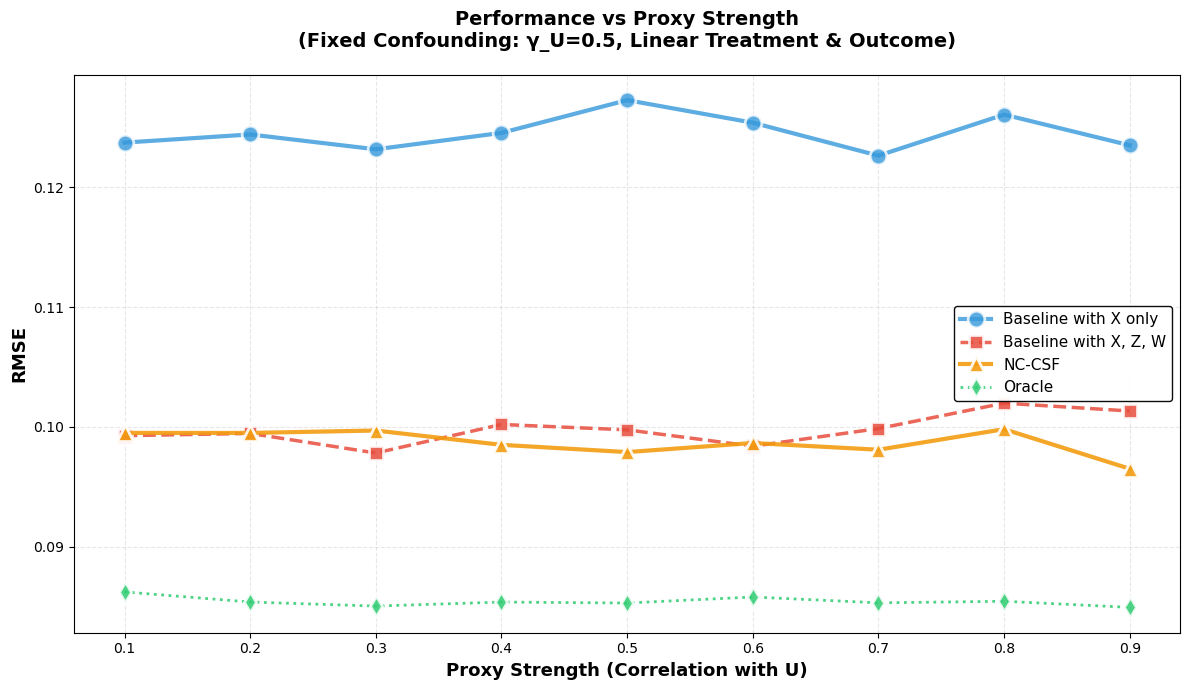

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Define proxy strength levels (correlation with U) and corresponding sigma values
# Based on the lookup table in the notebook
proxy_strengths = [
    {'corr': 0.1, 'sigma_z': 14.93, 'sigma_w': 14.93},
    {'corr': 0.2, 'sigma_z': 7.35, 'sigma_w': 7.35},
    {'corr': 0.3, 'sigma_z': 4.77, 'sigma_w': 4.77},
    {'corr': 0.4, 'sigma_z': 3.44, 'sigma_w': 3.44},
    {'corr': 0.5, 'sigma_z': 2.6, 'sigma_w': 2.6},
    {'corr': 0.6, 'sigma_z': 2.0, 'sigma_w': 2.0},
    {'corr': 0.7, 'sigma_z': 1.53, 'sigma_w': 1.53},
    {'corr': 0.8, 'sigma_z': 1.125, 'sigma_w': 1.125},
    {'corr': 0.9, 'sigma_z': 0.73, 'sigma_w': 0.73}
]

# Run experiments for each proxy strength level
print("Running experiments across proxy strength levels...")
all_results = []

for ps in proxy_strengths:
    print(f"  Running: Corr(Z,U) = {ps['corr']}, sigma = {ps['sigma_z']:.2f}...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=0.5,
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=0.5,
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=ps['sigma_z'], aW=1.5, sigma_w=ps['sigma_w'],
        linear_treatment=True, linear_outcome=True
    )
    
    results_df['Proxy_Corr'] = ps['corr']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# CORRECTED model names to match what run_experiment returns
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Proxy_Corr')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Proxy_Corr'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Proxy Strength (Correlation with U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Proxy Strength\n(Fixed Confounding: γ_U=0.5, Linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)

ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across confounding strength levels...
  Running: none confounding (γ_U=0.0, β_U=0.0)...
  Running: weak confounding (γ_U=0.1, β_U=0.1)...
  Running: weak confounding (γ_U=0.2, β_U=0.2)...
  Running: weak confounding (γ_U=0.3, β_U=0.3)...
  Running: weak confounding (γ_U=0.4, β_U=0.4)...
  Running: moderate confounding (γ_U=0.5, β_U=0.5)...
  Running: moderate confounding (γ_U=0.6, β_U=0.6)...
  Running: moderate confounding (γ_U=0.7, β_U=0.7)...
  Running: strong confounding (γ_U=0.9, β_U=0.9)...
  Running: strong confounding (γ_U=1.1, β_U=1.1)...
  Running: strong confounding (γ_U=1.2, β_U=1.2)...
  Running: extreme confounding (γ_U=1.4, β_U=1.4)...
  Running: strong confounding (γ_U=1.6, β_U=1.6)...
Baseline with X only: 13 points
Baseline with X, Z, W: 13 points
NC-CSF: 13 points
Oracle: 13 points


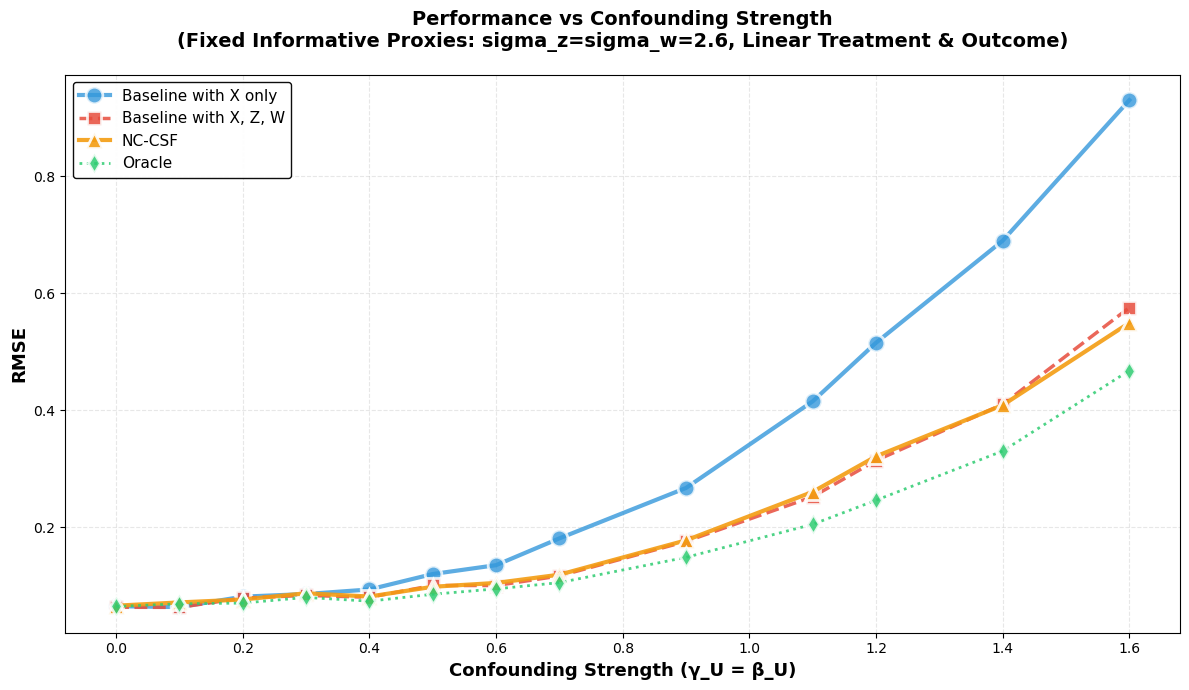

In [19]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Define confounding strength levels based on the table
confounding_strengths = [
    {'level': 'none', 'gamma_u_in_a': 0.0, 'beta_u_in_t': 0.0},
    {'level': 'weak', 'gamma_u_in_a': 0.1, 'beta_u_in_t': 0.1},
    {'level': 'weak', 'gamma_u_in_a': 0.2, 'beta_u_in_t': 0.2},
    {'level': 'weak', 'gamma_u_in_a': 0.3, 'beta_u_in_t': 0.3},
    {'level': 'weak', 'gamma_u_in_a': 0.4, 'beta_u_in_t': 0.4},
    {'level': 'moderate', 'gamma_u_in_a': 0.5, 'beta_u_in_t': 0.5},
    {'level': 'moderate', 'gamma_u_in_a': 0.6, 'beta_u_in_t': 0.6},
    {'level': 'moderate', 'gamma_u_in_a': 0.7, 'beta_u_in_t': 0.7},
    {'level': 'strong', 'gamma_u_in_a': 0.9, 'beta_u_in_t': 0.9},
    {'level': 'strong', 'gamma_u_in_a': 1.1, 'beta_u_in_t': 1.1},
    {'level': 'strong', 'gamma_u_in_a': 1.2, 'beta_u_in_t': 1.2},
    {'level': 'extreme', 'gamma_u_in_a': 1.4, 'beta_u_in_t': 1.4},
    {'level': 'strong', 'gamma_u_in_a': 1.6, 'beta_u_in_t': 1.6}
]

# Run experiments for each confounding strength level
print("Running experiments across confounding strength levels...")
all_results = []

for cs in confounding_strengths:
    print(f"  Running: {cs['level']} confounding (γ_U={cs['gamma_u_in_a']}, β_U={cs['beta_u_in_t']})...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=cs['gamma_u_in_a'],
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=cs['beta_u_in_t'],
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=2.6, aW=1.5, sigma_w=2.6,
        linear_treatment=True, linear_outcome=True
    )
    
    results_df['Confounding_Strength'] = cs['gamma_u_in_a']
    results_df['Confounding_Level'] = cs['level']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# Model names matching run_experiment output
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Confounding_Strength')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Confounding_Strength'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Confounding Strength (γ_U = β_U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Confounding Strength\n(Fixed Informative Proxies: sigma_z=sigma_w=2.6, Linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()